In [1]:
#simple 2-qubit Lindblad solver.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:
I = np.array([[1, 0],
              [0, 1]], dtype=complex)

X = np.array([[0, 1],
              [1, 0]], dtype=complex)

Y = np.array([[0, -1j],
              [1j, 0]], dtype=complex)

Z = np.array([[1, 0],
              [0, -1]], dtype=complex)

sigma_minus = np.array([[0, 1],
                        [0, 0]], dtype=complex)

sigma_plus = np.array([[0, 0],
                       [1, 0]], dtype=complex)

In [4]:
def kron(a, b):
    return np.kron(a, b)

In [5]:
I1 = kron(I, I)
X1 = kron(X, I)
X2 = kron(I, X)
Y1 = kron(Y, I)
Y2 = kron(I, Y)
Z1 = kron(Z, I)
Z2 = kron(I, Z)

sm1 = kron(sigma_minus, I)
sm2 = kron(I, sigma_minus)

In [6]:
ket_00 = np.array([1, 0, 0, 0], dtype=complex)
ket_11 = np.array([0, 0, 0, 1], dtype=complex)

psi_bell = (ket_00 + ket_11) / np.sqrt(2)

rho0 = np.outer(psi_bell, np.conjugate(psi_bell))

print(rho0)

[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]


In [7]:
def plot_density_matrix_abs(rho, title="|rho|"):
    plt.figure(figsize=(5, 4))
    plt.imshow(np.abs(rho))
    plt.colorbar()
    plt.xticks(range(4), ["00", "01", "10", "11"])
    plt.yticks(range(4), ["00", "01", "10", "11"])
    plt.title(title)
    plt.tight_layout()
    plt.show()

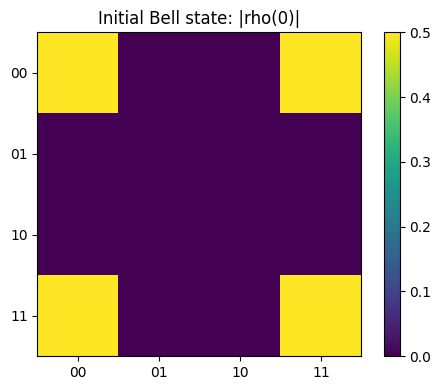

In [8]:
plot_density_matrix_abs(rho0, title="Initial Bell state: |rho(0)|")

In [9]:
#Lidblad RHS 
def lindblad_rhs(t, rho_flat, H, L_list, gamma_list):
    rho = rho_flat.reshape((4, 4))

    # część hamiltonianowa
    drho = -1j * (H @ rho - rho @ H)

    # część dissipacyjna
    for L, gamma in zip(L_list, gamma_list):
        jump = L @ rho @ L.conj().T
        anti = L.conj().T @ L @ rho + rho @ L.conj().T @ L
        drho += gamma * (jump - 0.5 * anti)

    return drho.flatten()

In [10]:
#solver 
def solve_lindblad(rho0, H, L_list, gamma_list, t_eval):
    result = solve_ivp(
        fun=lambda t, y: lindblad_rhs(t, y, H, L_list, gamma_list),
        t_span=(t_eval[0], t_eval[-1]),
        y0=rho0.flatten(),
        t_eval=t_eval
    )

    rhos = []
    for i in range(len(result.t)):
        rho_t = result.y[:, i].reshape((4, 4))
        rhos.append(rho_t)

    return result.t, rhos

In [11]:
#without hamiltonian 
H = np.zeros((4, 4), dtype=complex)

gamma_phi_1 = 0.1
gamma_phi_2 = 0.1

L_list = [Z1, Z2]
gamma_list = [gamma_phi_1, gamma_phi_2]

t_eval = np.linspace(0, 20, 200)

times, rhos = solve_lindblad(rho0, H, L_list, gamma_list, t_eval)

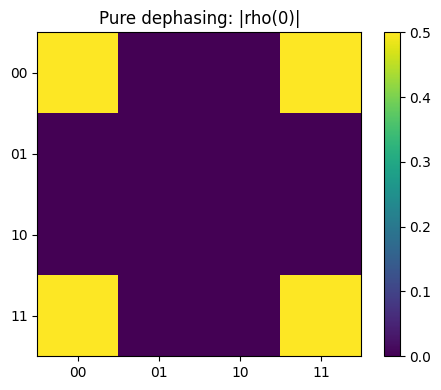

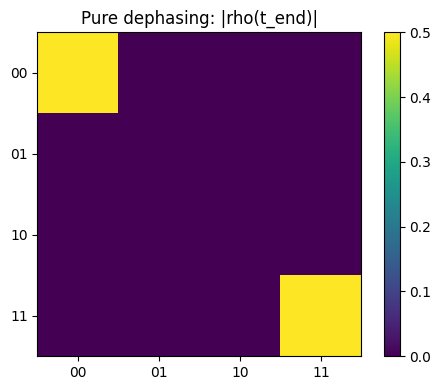

In [12]:
#show start and end matrices 
plot_density_matrix_abs(rhos[0], title="Pure dephasing: |rho(0)|")
plot_density_matrix_abs(rhos[-1], title="Pure dephasing: |rho(t_end)|")

In [13]:
#what is with rho00,11
coherence = [np.abs(rho[0, 3]) for rho in rhos]
pop_00 = [np.real(rho[0, 0]) for rho in rhos]
pop_11 = [np.real(rho[3, 3]) for rho in rhos]

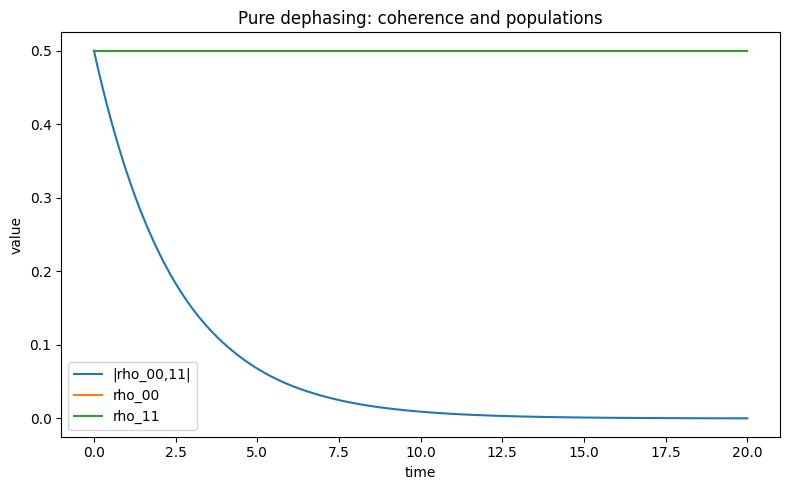

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(times, coherence, label="|rho_00,11|")
plt.plot(times, pop_00, label="rho_00")
plt.plot(times, pop_11, label="rho_11")
plt.xlabel("time")
plt.ylabel("value")
plt.title("Pure dephasing: coherence and populations")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
#relax
gamma_relax_1 = 0.1
gamma_relax_2 = 0.1

L_list_relax = [sm1, sm2]
gamma_list_relax = [gamma_relax_1, gamma_relax_2]

times_relax, rhos_relax = solve_lindblad(rho0, H, L_list_relax, gamma_list_relax, t_eval)

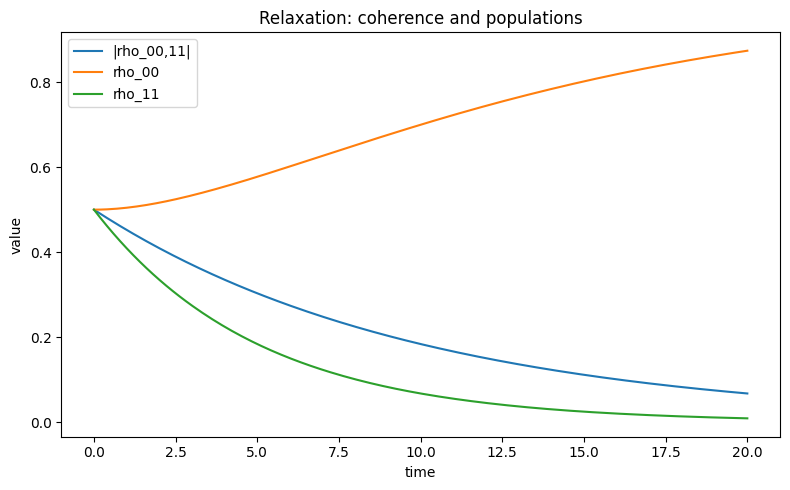

In [16]:
coherence_relax = [np.abs(rho[0, 3]) for rho in rhos_relax]
pop_00_relax = [np.real(rho[0, 0]) for rho in rhos_relax]
pop_11_relax = [np.real(rho[3, 3]) for rho in rhos_relax]

plt.figure(figsize=(8, 5))
plt.plot(times_relax, coherence_relax, label="|rho_00,11|")
plt.plot(times_relax, pop_00_relax, label="rho_00")
plt.plot(times_relax, pop_11_relax, label="rho_11")
plt.xlabel("time")
plt.ylabel("value")
plt.title("Relaxation: coherence and populations")
plt.legend()
plt.tight_layout()
plt.show()

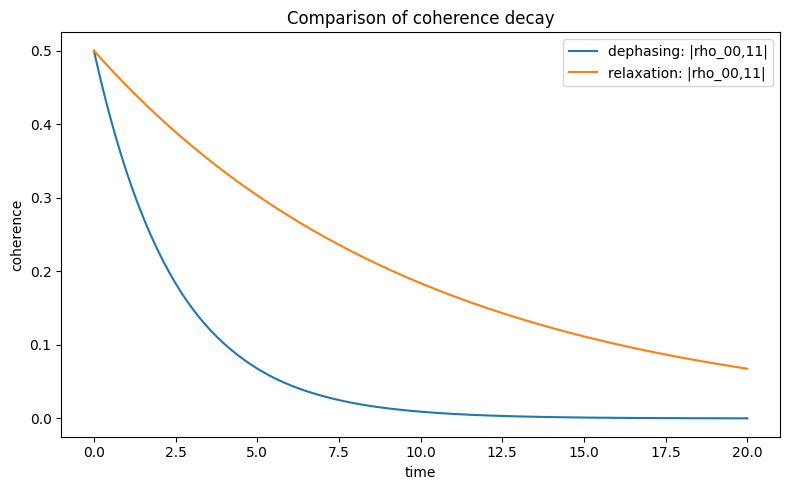

In [17]:
#comparison
plt.figure(figsize=(8, 5))
plt.plot(times, coherence, label="dephasing: |rho_00,11|")
plt.plot(times_relax, coherence_relax, label="relaxation: |rho_00,11|")
plt.xlabel("time")
plt.ylabel("coherence")
plt.title("Comparison of coherence decay")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#dephasing + relax 
L_list_both = [Z1, Z2, sm1, sm2]
gamma_list_both = [0.05, 0.05, 0.05, 0.05]

times_both, rhos_both = solve_lindblad(rho0, H, L_list_both, gamma_list_both, t_eval)